<a href="https://colab.research.google.com/github/EdmundShea/google_colab/blob/main/notebook48ba9c0a0e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

edmundhkg_titanic_data_path = kagglehub.dataset_download('edmundhkg/titanic-data')
edmundhkg_yotel_all_path = kagglehub.dataset_download('edmundhkg/yotel-all')

print('Data source import complete.')


Data source import complete.


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/edmundhkg/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/root/.cache/kagglehub/datasets/edmundhkg/yotel-all/1.complete
/root/.cache/kagglehub/datasets/edmundhkg/yotel-all/versions/1/yotel_all.csv
/root/.cache/kagglehub/datasets/edmundhkg/titanic-data/1.complete
/root/.cache/kagglehub/datasets/edmundhkg/titanic-data/versions/1/titanic.csv


In [5]:
import os
import pandas as pd

titanic_file_path = os.path.join(edmundhkg_titanic_data_path, 'titanic.csv')
titanic_df = pd.read_csv(titanic_file_path)
print(titanic_df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

### Exploring 'Sex' and 'Survived' Columns

In [6]:
# Value counts for 'Sex' column
print("Value counts for 'Sex' column:")
print(titanic_df['Sex'].value_counts())

print("\n" + "-" * 30 + "\n")

# Value counts for 'Survived' column
print("Value counts for 'Survived' column:")
print(titanic_df['Survived'].value_counts())


Value counts for 'Sex' column:
Sex
male      577
female    314
Name: count, dtype: int64

------------------------------

Value counts for 'Survived' column:
Survived
0    549
1    342
Name: count, dtype: int64


From the value counts, we can see the distribution of males and females, and the number of passengers who survived (1) versus those who did not (0). Let's now look at the survival rate based on sex.

In [7]:
# Calculate survival rate by 'Sex'
survival_by_sex = titanic_df.groupby('Sex')['Survived'].mean().reset_index()
survival_by_sex['Survived'] = survival_by_sex['Survived'] * 100 # Convert to percentage

print("Survival rate by Sex (%):")
print(survival_by_sex)


Survival rate by Sex (%):
      Sex   Survived
0  female  74.203822
1    male  18.890815


The results indicate a significant difference in survival rates between males and females. Let's visualize this using a bar plot for better clarity.

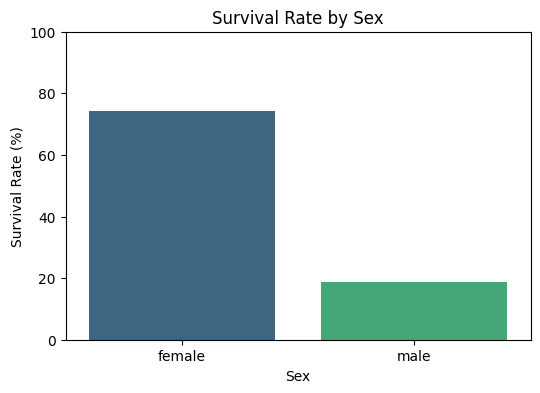

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize survival rate by sex
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=survival_by_sex, palette='viridis', hue='Sex', legend=False)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()


### Exploring 'Pclass' and 'Survived' Columns

In [10]:
# Calculate survival rate by 'Pclass'
survival_by_pclass = titanic_df.groupby('Pclass')['Survived'].mean().reset_index()
survival_by_pclass['Survived'] = survival_by_pclass['Survived'] * 100 # Convert to percentage

print("Survival rate by Pclass (%):")
print(survival_by_pclass)


Survival rate by Pclass (%):
   Pclass   Survived
0       1  62.962963
1       2  47.282609
2       3  24.236253


The results show how survival rates varied across different passenger classes. Let's visualize this relationship with a bar plot.

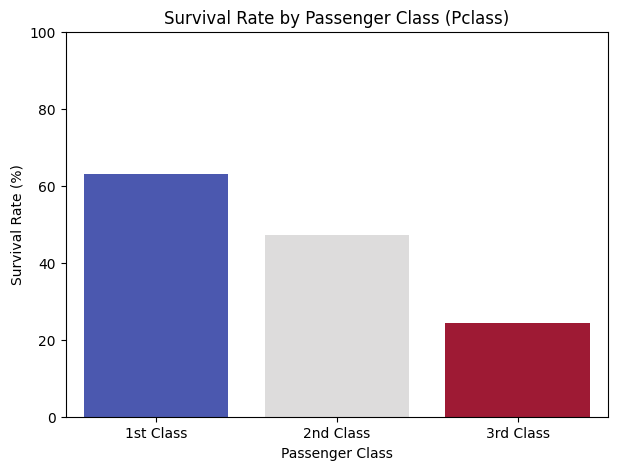

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize survival rate by Pclass
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=survival_by_pclass, palette='coolwarm', hue='Pclass', legend=False)
plt.title('Survival Rate by Passenger Class (Pclass)')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class']) # Label Pclass for clarity
plt.show()
